---
title: Sea surface height from the MESACLIP historical run
author: Harsha R. Hampapura
date: 2026-08-10
---

## Sea surface height from MESACLIP

This is a **minimal** example: open the [MESACLIP](https://gdex.ucar.edu/datasets/d651007/)
high-resolution (0.1° ocean) CESM iHESP historical simulation from GDEX and plot a
single day of **sea surface height**. For a fuller workflow — regridding to a regular
grid and building an interactive map — see the companion notebook
[MESACLIP SST regridding](./mesaclip_regrid_sst.ipynb).

The data is served as a [kerchunk](https://fsspec.github.io/kerchunk/) reference over
the underlying model output, so one `xr.open_dataset(..., engine="kerchunk")` call
exposes the whole daily record as a virtual `xarray.Dataset`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# On NCAR HPC (Casper/Derecho) — direct POSIX access:
store = "/gdex/data/d651007/kerchunk/b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005.010.ocn.day_1.parq"

# Off-cluster (stream over the web) — use this instead:
# store = "https://data.gdex.ucar.edu/d651007/kerchunk/b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005.010.ocn.day_1-remote-https.parq"

In [3]:
ds = xr.open_dataset(store, engine="kerchunk", decode_timedelta=False, chunks={})
ds

/glade/u/home/harshah/.conda/envs/osdf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 74TB
Dimensions:             (time: 31390, nlat: 2400, nlon: 3600, z_t: 62, z_w: 62,
                         d2: 2, z_t_150m: 15, z_w_bot: 62, z_w_top: 62)
Coordinates:
  * time                (time) object 251kB 1920-01-02 00:00:00 ... 2006-01-0...
  * z_t                 (z_t) float32 248B 500.0 1.5e+03 ... 5.625e+05 5.875e+05
  * z_w                 (z_w) float32 248B 0.0 1e+03 2e+03 ... 5.5e+05 5.75e+05
  * z_t_150m            (z_t_150m) float32 60B 500.0 1.5e+03 ... 1.45e+04
  * z_w_bot             (z_w_bot) float32 248B 1e+03 2e+03 ... 5.75e+05 6e+05
  * z_w_top             (z_w_top) float32 248B 0.0 1e+03 ... 5.5e+05 5.75e+05
    TLAT                (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    TLONG               (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    ULAT                (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    ULONG               (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon, d2
Data variables: (12/76)
    ANGLE               (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    ANGLET              (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    DXT                 (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    DXU                 (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    DYT                 (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    DYU                 (time, nlat, nlon) float64 2TB dask.array<chunksize=(1, 480, 720), meta=np.ndarray>
    ...                  ...
    sea_ice_salinity    (time) float64 251kB dask.array<chunksize=(1,), meta=np.ndarray>
    sflux_factor        (time) float64 251kB dask.array<chunksize=(1,), meta=np.ndarray>
    sound               (time) float64 251kB dask.array<chunksize=(1,), meta=np.ndarray>
    stefan_boltzmann    (time) float64 251kB dask.array<chunksize=(1,), meta=np.ndarray>
    time_bound          (time, d2) object 502kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vonkar              (time) float64 251kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    title:           b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.46-1920-2005...
    history:         none
    Conventions:     CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netcdf/CF-curr...
    contents:        Diagnostic and Prognostic Variables
    source:          CCSM POP2, the CCSM Ocean Component
    revision:        $Id: tavg.F90 56176 2013-12-20 18:35:46Z mlevy@ucar.edu $
    calendar:        All years have exactly  365 days.
    start_time:      This dataset was created on 2023-11-30 at 21:10:48.7
    cell_methods:    cell_methods = time: mean ==> the variable values are av...
    nsteps_total:    611
    tavg_sum:        84600.0
    tavg_sum_qflux:  84600.0

The sea-surface-height field is `SSH_2` (long name *"Sea Surface Height"*, units cm) on
the model's 0.1° tripole grid, with 2D geographic coordinates `TLAT`/`TLONG`. We pull one
day and its grid — everything else stays lazy.

In [5]:
import cftime

# CESM uses a no-leap (365-day) calendar, so time is a cftime index, not datetime64.
# Select with a matching cftime object rather than a string.
target = cftime.DatetimeNoLeap(2000, 1, 1)
day = ds["SSH_2"].sel(time=target, method="nearest").load()   # cm
lat = ds["TLAT"].isel(time=0).load()
lon = ds["TLONG"].isel(time=0).load()
day

<xarray.DataArray 'SSH_2' (nlat: 2400, nlon: 3600)> Size: 35MB
array([[-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]],
      shape=(2400, 3600), dtype=float32)
Coordinates:
    TLAT     (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
    TLONG    (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
    ULAT     (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
    ULONG    (nlat, nlon) float64 69MB nan nan nan nan nan ... nan nan nan nan
    time     object 8B 2000-01-01 00:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Sea Surface Height
    units:         centimeter
    grid_loc:      2110
    cell_methods:  time: mean

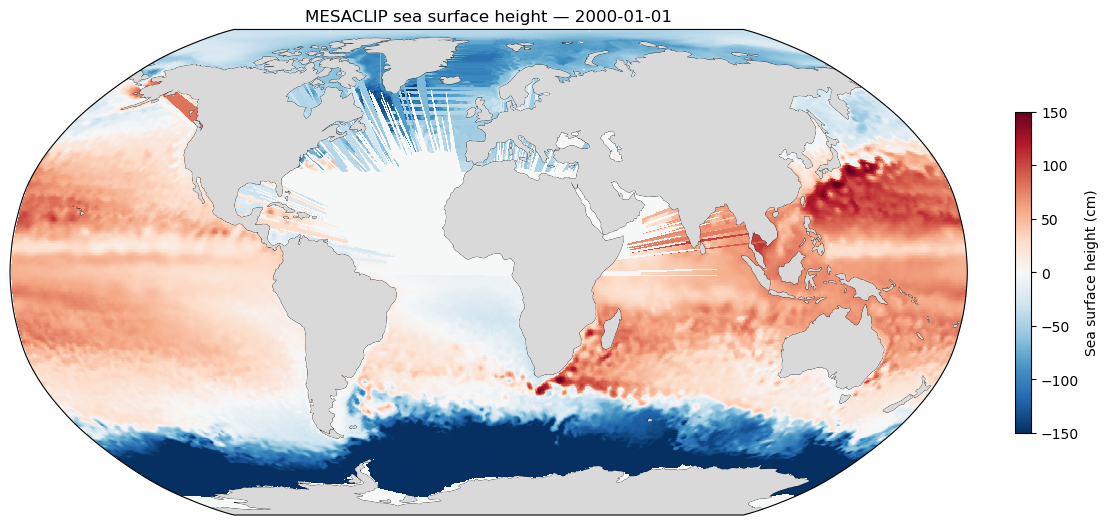

In [6]:
# coarsen 5× for a light global plot (2400×3600 → 480×720)
c = 5
ssh = day.coarsen(nlat=c, nlon=c, boundary="trim").mean()
la  = lat.coarsen(nlat=c, nlon=c, boundary="trim").mean()
lo  = lon.coarsen(nlat=c, nlon=c, boundary="trim").mean()

fig, ax = plt.subplots(figsize=(11, 5.5), subplot_kw={"projection": ccrs.Robinson()},
                       constrained_layout=True)
p = ax.pcolormesh(lo, la, ssh, transform=ccrs.PlateCarree(),
                  cmap="RdBu_r", vmin=-150, vmax=150, shading="auto")
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
ax.coastlines(linewidth=0.4)
ax.set_global()
plt.colorbar(p, ax=ax, shrink=0.6, label="Sea surface height (cm)")
ax.set_title(f"MESACLIP sea surface height — {str(day.time.values)[:10]}")
plt.show()